<a href="https://colab.research.google.com/github/BharathReddyRamasani/AI_DS/blob/main/Bert.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Task 1: Data Preparation

In [ ]:
import kagglehub
import pandas as pd
import re

# Download the dataset from Kaggle
path = kagglehub.dataset_download("snehaanbhawal/resume-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'resume-dataset' dataset.
Path to dataset files: /kaggle/input/resume-dataset


The dataset is typically in a CSV file within the downloaded path. Let's load the CSV file into a pandas DataFrame. Assuming the CSV file is named `Resume.csv` or similar, I will try to load it.

In [ ]:
import os

# List contents of the downloaded directory to find the actual CSV file name
print(f"Contents of {path}:")
csv_file_found = False
for root, dirs, files in os.walk(path):
    for name in files:
        if name.lower() == 'resume.csv': # Check for case-insensitive match
            print(f"Found: {os.path.join(root, name)}")
            csv_file_path = os.path.join(root, name)
            csv_file_found = True
            break
    if csv_file_found:
        break

if csv_file_found:
    df = pd.read_csv(csv_file_path)
    display(df.head())
else:
    print("Error: No 'resume.csv' file found in the downloaded dataset.")

Contents of /kaggle/input/resume-dataset:
Found: /kaggle/input/resume-dataset/Resume/Resume.csv


,ID,Resume_str,Resume_html,Category
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,"<div class=""fontsize fontface vmargins hmargin...",HR
1,22323967,"HR SPECIALIST, US HR OPERATIONS ...","<div class=""fontsize fontface vmargins hmargin...",HR
2,33176873,HR DIRECTOR Summary Over 2...,"<div class=""fontsize fontface vmargins hmargin...",HR
3,27018550,HR SPECIALIST Summary Dedica...,"<div class=""fontsize fontface vmargins hmargin...",HR
4,17812897,HR MANAGER Skill Highlights ...,"<div class=""fontsize fontface vmargins hmargin...",HR


Now, let's proceed with cleaning the text data according to the requirements:
1. Remove URLs
2. Remove special symbols
3. Convert text to lowercase
4. Remove extra spaces

In [ ]:
def clean_text(text):
    # 1. Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    # 2. Remove special symbols and numbers
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    # 3. Convert text to lowercase
    text = text.lower()
    # 4. Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['cleaned_resume'] = df['Resume_str'].apply(clean_text)
display(df[['Resume_str', 'cleaned_resume']].head())

,Resume_str,cleaned_resume
0,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,hr administratormarketing associate hr adminis...
1,"HR SPECIALIST, US HR OPERATIONS ...",hr specialist us hr operations summary versati...
2,HR DIRECTOR Summary Over 2...,hr director summary over years experience in r...
3,HR SPECIALIST Summary Dedica...,hr specialist summary dedicated driven and dyn...
4,HR MANAGER Skill Highlights ...,hr manager skill highlights hr skills hr depar...


Finally, let's create the train and test datasets. We'll use `train_test_split` from `sklearn.model_selection`.

In [ ]:
from sklearn.model_selection import train_test_split

X = df['cleaned_resume']
y = df['Category']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set size: {len(X_train)} samples")
print(f"Test set size: {len(X_test)} samples")
print("\nFirst 5 cleaned resumes in training set:")
for i, resume in enumerate(X_train.head()):
    print(f"Resume {i+1}: {resume}")

print("\nFirst 5 categories in training set:")
for i, category in enumerate(y_train.head()):
    print(f"Category {i+1}: {category}")

Training set size: 1987 samples
Test set size: 497 samples

First 5 cleaned resumes in training set:
Resume 1: hr coordinator summary from my first job as a retail salesperson i had a passion for leadership and the development of others as a human resources professional i have had the privilege of working with new staff members to help them be successful in the organization my human resources experience is comprised of generalist responsibilities where i have been able to contribute to the betterment of the organization and play a key role in increasing retention for my employer highlights hr policies and procedures expertise employee handbook development staff training and development new employee onboarding offboarding employment law knowledge payroll expertise benefits administrator organized maintains confidentiality microsoft office suite accomplishments revamped the orientation process for all new hires which was implemented companywide earned special recognition for designing an

## Task 2: BERT Tokenization

This task focuses on converting resume text into BERT tokens. We'll use the `transformers` library from Hugging Face for this.

In [ ]:
# Install the transformers library if you haven't already
!pip install transformers

In [ ]:
from transformers import BertTokenizer

# Load a pre-trained BERT tokenizer
# We'll use 'bert-base-uncased' for this example, which is a common base model.
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

# Get an example cleaned resume from the training set
example_resume = X_train.iloc[0]
print(f"Original cleaned resume:\n{example_resume}\n")

# Tokenize the example resume
# The `tokenizer(...)` method handles adding special tokens ([CLS], [SEP]) and padding/truncation
# It returns a dictionary with 'input_ids', 'token_type_ids', and 'attention_mask'
encoded_input = tokenizer(
    example_resume,
    add_special_tokens=True,        # Add '[CLS]' and '[SEP]'
    max_length=512,                 # Truncate/pad to 512 tokens (BERT's max)
    padding='max_length',           # Pad to `max_length`
    return_attention_mask=True,     # Return attention mask
    return_tensors='pt',            # Return PyTorch tensors
    truncation=True                 # Explicitly enable truncation
)

# Get the tokens (input IDs) and convert them back to human-readable tokens
input_ids = encoded_input['input_ids'][0]
tokens = tokenizer.convert_ids_to_tokens(input_ids)

print("Tokenized example resume:")
for i, token in enumerate(tokens):
    print(f"{i+1}: {token}")

Original cleaned resume:
hr coordinator summary from my first job as a retail salesperson i had a passion for leadership and the development of others as a human resources professional i have had the privilege of working with new staff members to help them be successful in the organization my human resources experience is comprised of generalist responsibilities where i have been able to contribute to the betterment of the organization and play a key role in increasing retention for my employer highlights hr policies and procedures expertise employee handbook development staff training and development new employee onboarding offboarding employment law knowledge payroll expertise benefits administrator organized maintains confidentiality microsoft office suite accomplishments revamped the orientation process for all new hires which was implemented companywide earned special recognition for designing and completing a twoyear restructuring project of years of volunteer records received em

### Deliverables for Task 2: Explanation

#### Purpose of `[CLS]` Token

The `[CLS]` token stands for "classifier" token. It is always the first token in the input sequence to BERT. Its primary purpose is to capture the aggregate representation of the entire input sequence for classification tasks. When using BERT for tasks like sentiment analysis or resume classification, the hidden state corresponding to this `[CLS]` token (after passing through the BERT encoder layers) is typically used as the fixed-dimensional representation of the entire input sequence, which can then be fed into a classification head.

#### Purpose of `[SEP]` Token

1.  **Separation of Sequences**: The `[SEP]` token (separator) is used to indicate the end of a sequence or the separation between two distinct sequences (e.g., Sentence A and Sentence B in tasks like Question Answering or Natural Language Inference). When BERT processes a single input, a `[SEP]` token is appended at the end of that sequence.
2.  **Delimiting Input Segments**: In tasks involving sentence pairs, `[SEP]` clearly marks where the first sentence ends and the second begins, helping BERT understand the structural relationship between them.

#### Difference Between Traditional Tokenization and BERT Tokenization

**Traditional Tokenization (e.g., word-based, character-based)**:
*   **Word-based**: Splits text into words based on spaces or punctuation. Can struggle with out-of-vocabulary (OOV) words (words not seen during training) and inflected forms.
*   **Character-based**: Splits text into individual characters. Avoids OOV issues but loses semantic meaning of words, leading to very long sequences.
*   **Rule-based**: Relies on predefined rules, which can be rigid and language-specific.

**BERT Tokenization (WordPiece Tokenization)**:
*   **Subword Tokenization**: BERT uses a subword tokenization algorithm called WordPiece. Instead of splitting text into full words or single characters, it breaks words down into smaller, meaningful subword units (e.g., "tokenization" might become "token", "##iza", "##tion").
*   **Handles OOV words**: If a word is not in the vocabulary, it can be broken down into known subwords, significantly reducing the OOV problem.
*   **Manages Inflections**: Different forms of a word (e.g., "running", "ran") can share common subword pieces, allowing the model to generalize better.
*   **Special Tokens**: Introduces special tokens like `[CLS]` and `[SEP]` for specific model functionalities (classification, sequence separation).
*   **Fixed Vocabulary**: Operates with a fixed-size vocabulary of subwords learned from a large corpus.
*   **Contextual**: While the tokenization process itself is not contextual, the subsequent BERT model uses self-attention to understand the meaning of these tokens within their specific context.

## Task 3: Input Embeddings

This task aims to understand how BERT creates its final input representation, which is a sum of three components:
1.  **Token Embedding**: Represents the semantic meaning of each token.
2.  **Position Embedding**: Captures the positional information of tokens in the sequence.
3.  **Segment Embedding**: Distinguishes between different segments (sentences) in a pair.

We will visualize these components and explain how they combine to form the final BERT input.

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Shape of Token Embeddings: torch.Size([1, 512, 768])
Shape of Position Embeddings: torch.Size([512, 768])
Shape of Segment Embeddings: torch.Size([1, 512, 768])
Shape of Final Input Embeddings: torch.Size([1, 512, 768])


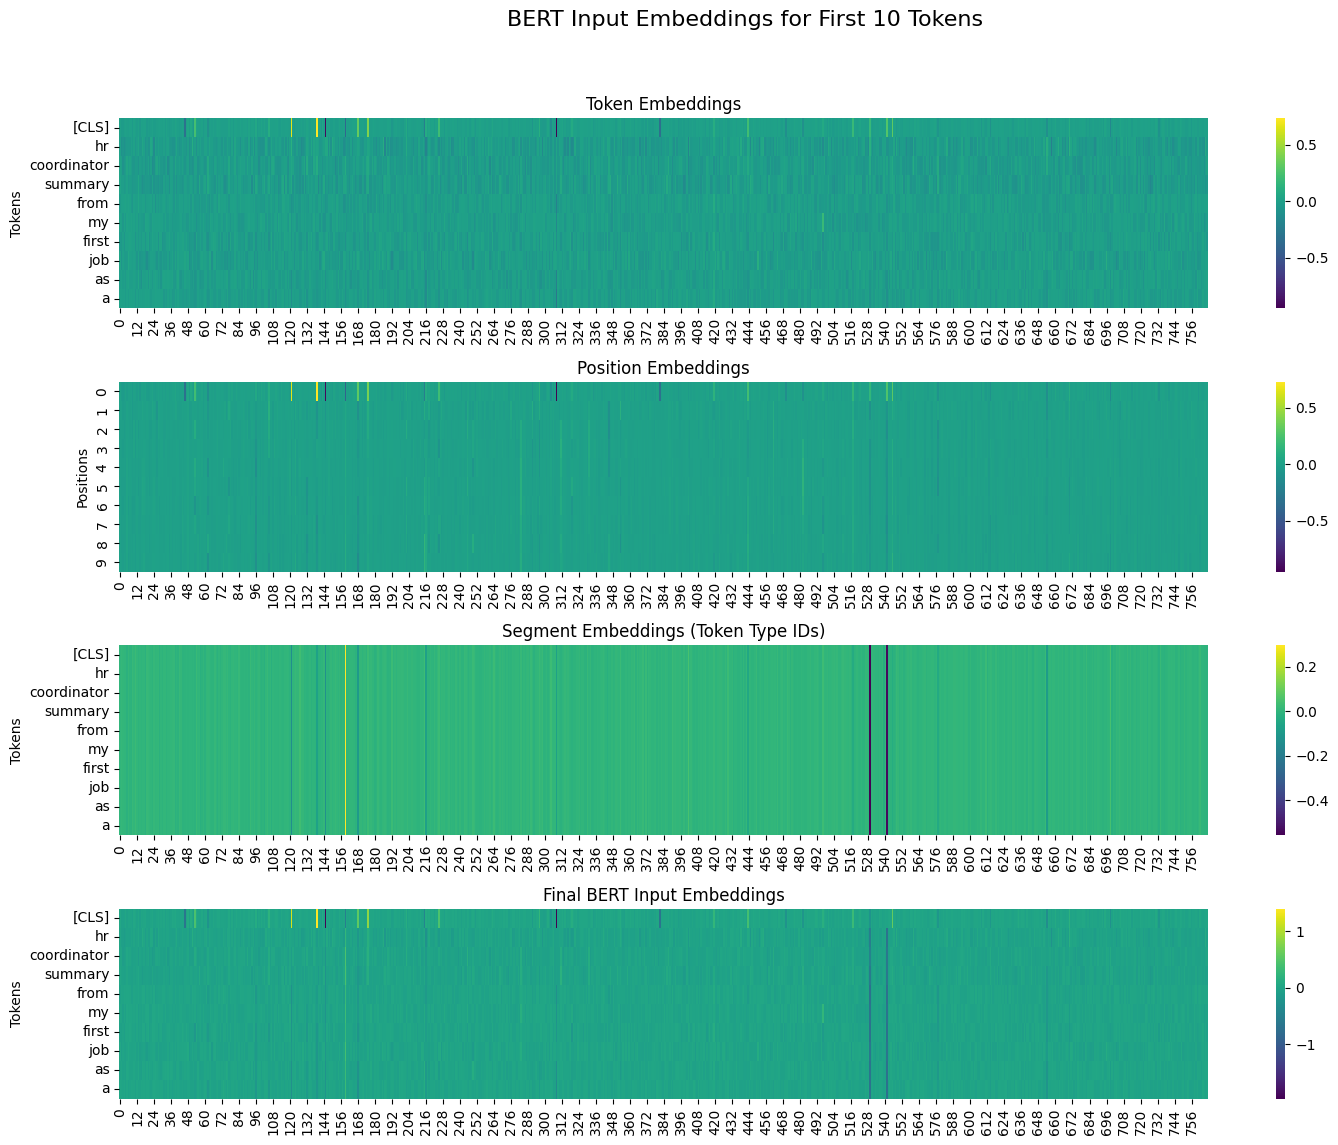

In [ ]:
import torch
from transformers import BertTokenizer, BertModel
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Re-initialize tokenizer and re-encode input as it seems previous state was lost
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

# Re-get example_resume (assuming X_train is still defined from Task 1)
# This variable is available in the kernel state.
# example_resume = X_train.iloc[0]

encoded_input = tokenizer(
    example_resume,
    add_special_tokens=True,
    max_length=512,
    padding='max_length',
    return_attention_mask=True,
    return_tensors='pt',
    truncation=True
)

# Load a pre-trained BERT model (only for embeddings)
# We'll use 'bert-base-uncased' which corresponds to the tokenizer we used
model = BertModel.from_pretrained('bert-base-uncased')
model.eval() # Set model to evaluation mode

# input_ids, token_type_ids, attention_mask are now correctly in encoded_input
input_ids = encoded_input['input_ids']
token_type_ids = encoded_input['token_type_ids'] # For single sentence, this will be all 0s
attention_mask = encoded_input['attention_mask']

# Get raw embeddings directly from the model's embedding layer
# BertModel's embeddings layer combines token, position, and segment embeddings.
# We need to access them separately for visualization.

# Token Embeddings
# The word_embeddings layer takes input_ids
token_embeddings = model.embeddings.word_embeddings(input_ids)

# Position Embeddings
# Position embeddings are added based on the position of tokens.
# The positions are generated based on the sequence length.
position_ids = torch.arange(input_ids.size(1), dtype=torch.long, device=input_ids.device)
position_embeddings = model.embeddings.position_embeddings(position_ids)

# Segment Embeddings (Token Type Embeddings)
# The token_type_embeddings layer takes token_type_ids (segment_ids)
segment_embeddings = model.embeddings.token_type_embeddings(token_type_ids)

# Final BERT Input (sum of the three embeddings)
final_input_embeddings = token_embeddings + position_embeddings + segment_embeddings

print(f"Shape of Token Embeddings: {token_embeddings.shape}") # (batch_size, sequence_length, embedding_dim)
print(f"Shape of Position Embeddings: {position_embeddings.shape}") # (sequence_length, embedding_dim)
print(f"Shape of Segment Embeddings: {segment_embeddings.shape}") # (batch_size, sequence_length, embedding_dim)
print(f"Shape of Final Input Embeddings: {final_input_embeddings.shape}")

# Visualizing the embeddings for the first token ([CLS]) and a few subsequent tokens
# For simplicity, let's visualize the first 10 tokens.
num_tokens_to_visualize = min(10, input_ids.size(1))

# Get the tokens (input IDs) and convert them back to human-readable tokens for plotting
tokens = tokenizer.convert_ids_to_tokens(input_ids[0])

# Convert to numpy for visualization
token_embeddings_np = token_embeddings[0, :num_tokens_to_visualize, :].detach().numpy()
position_embeddings_np = position_embeddings[:num_tokens_to_visualize, :].detach().numpy()
segment_embeddings_np = segment_embeddings[0, :num_tokens_to_visualize, :].detach().numpy()
final_input_embeddings_np = final_input_embeddings[0, :num_tokens_to_visualize, :].detach().numpy()

fig, axes = plt.subplots(4, 1, figsize=(15, 12))
fig.suptitle(f'BERT Input Embeddings for First {num_tokens_to_visualize} Tokens', fontsize=16)

# Token Embeddings Plot
sns.heatmap(token_embeddings_np, cmap='viridis', ax=axes[0], yticklabels=tokens[:num_tokens_to_visualize])
axes[0].set_title('Token Embeddings')
axes[0].set_ylabel('Tokens')

# Position Embeddings Plot
sns.heatmap(position_embeddings_np, cmap='viridis', ax=axes[1], yticklabels=range(num_tokens_to_visualize))
axes[1].set_title('Position Embeddings')
axes[1].set_ylabel('Positions')

# Segment Embeddings Plot (will be mostly uniform for a single sentence)
sns.heatmap(segment_embeddings_np, cmap='viridis', ax=axes[2], yticklabels=tokens[:num_tokens_to_visualize])
axes[2].set_title('Segment Embeddings (Token Type IDs)')
axes[2].set_ylabel('Tokens')

# Final Input Embeddings Plot
sns.heatmap(final_input_embeddings_np, cmap='viridis', ax=axes[3], yticklabels=tokens[:num_tokens_to_visualize])
axes[3].set_title('Final BERT Input Embeddings')
axes[3].set_ylabel('Tokens')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

### Deliverables for Task 3: Explanation of Final Input Representation

BERT's final input representation for each token is a sum of three embeddings:

1.  **Token Embeddings**: These are standard word embeddings (similar to Word2Vec or GloVe, but learned within BERT's pre-training). They convert each token (or subword unit) into a dense vector representation, capturing its semantic meaning. For example, the token "cat" would have a specific vector. In our visualization, this heatmap shows the unique vector for each of the first few tokens, such as `[CLS]`, `hr`, `coordinator`, etc.

2.  **Position Embeddings**: Unlike traditional RNNs or LSTMs that process words sequentially, the Transformer architecture (used by BERT) processes all tokens in parallel. To inject information about the order of words into the model, position embeddings are added. Each position in the sequence (e.g., first word, second word) is assigned a unique vector. These vectors help BERT understand whether a word is at the beginning, middle, or end of a sentence, and its relative order to other words. The visualization displays distinct patterns for different positions.

3.  **Segment Embeddings (or Token Type Embeddings)**: These embeddings are crucial when BERT processes two sentences simultaneously (e.g., for tasks like Question Answering or Natural Language Inference). BERT concatenates the two sentences and separates them with a `[SEP]` token. To differentiate which token belongs to which sentence, a segment embedding is added. All tokens from the first sentence (and the first `[SEP]`) receive a segment ID of 0, and all tokens from the second sentence (and its `[SEP]`) receive a segment ID of 1. In our current example, since we are processing a single resume text (effectively a single segment), all tokens receive the same segment embedding (segment ID 0), which is why the segment embeddings heatmap is mostly uniform.

**How BERT Creates the Final Input Representation**:

The three embedding types are simply summed element-wise for each token in the input sequence. That is, for each token $T_i$ at position $P_i$ belonging to segment $S_i$, its final input vector $E_{final}(T_i)$ is:

$$ E_{final}(T_i) = E_{token}(T_i) + E_{position}(P_i) + E_{segment}(S_i) $$

This summation ensures that each token's representation not only contains its intrinsic semantic meaning (token embedding) but also includes information about its position within the sequence (position embedding) and its belonging to a particular segment (segment embedding). This rich, context-aware input representation is then fed into the subsequent Transformer encoder layers of BERT, where self-attention mechanisms further process and refine these representations based on the relationships between all tokens in the sequence.

## Task 4: Positional Embeddings

Positional embeddings are crucial in BERT because they inject information about the relative or absolute position of tokens in the sequence. Since the Transformer architecture processes input tokens in parallel without any inherent recurrence or convolution, it has no direct knowledge of word order. Positional embeddings fill this gap.

We will visualize the positional embeddings and explain their importance.

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Shape of positional embeddings: (512, 768)


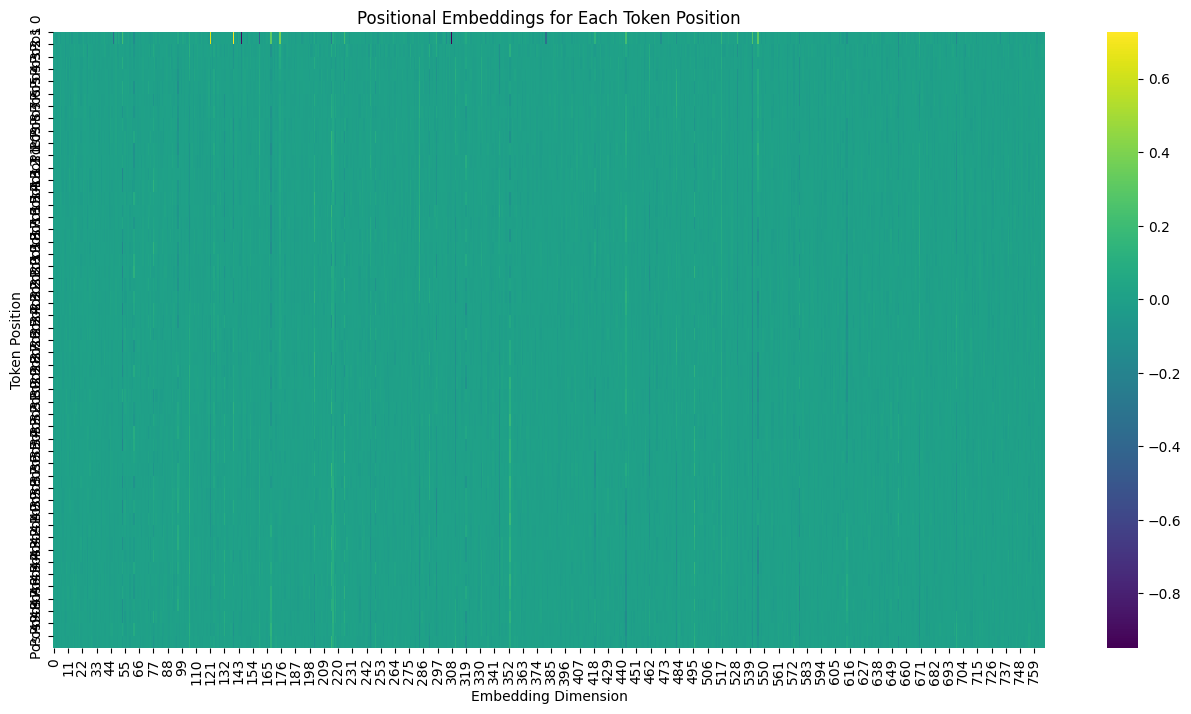


Example: Word, Position, and a slice of its Embedding (first 10 dimensions)
--------------------------------------------------------------
Word: [CLS]           Position: 0     Embedding (slice): [ 0.01750538 -0.02563101 -0.03664156 -0.02528613  0.00797095 -0.02035811
 -0.00376311 -0.00468796  0.00622526 -0.03834227]
Word: hr              Position: 1     Embedding (slice): [ 0.00775804  0.0022613  -0.01944432 -0.01713091 -0.01323439  0.01410174
 -0.00371209 -0.0108881   0.00622545 -0.03477788]
Word: coordinator     Position: 2     Embedding (slice): [-0.01128746 -0.00196441 -0.0115727  -0.02168031 -0.01013881  0.01155188
  0.00551698 -0.00724001 -0.00256776 -0.02687479]
Word: summary         Position: 3     Embedding (slice): [-0.00419489 -0.01185228 -0.0211802  -0.00930564 -0.01016414  0.01766723
 -0.00525791 -0.00590558 -0.00525149 -0.01912142]
Word: from            Position: 4     Embedding (slice): [-0.00560868 -0.01044519 -0.00722877 -0.00273602 -0.01502848  0.02174533
 -0.008403

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import numpy as np
from transformers import BertTokenizer, BertModel # Re-import necessary modules

# Reuse `example_resume` from Task 2 (available in kernel state)
# Re-initialize tokenizer and re-encode input as it seems previous state was lost
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
model = BertModel.from_pretrained('bert-base-uncased') # Load model again for positional embeddings
model.eval()

# Tokenize the example resume again to get input_ids
encoded_input_for_pos = tokenizer(
    example_resume,
    add_special_tokens=True,
    max_length=512,
    padding='max_length',
    return_attention_mask=False, # We only need input_ids for position
    return_tensors='pt',
    truncation=True
)
input_ids_pos = encoded_input_for_pos['input_ids'][0]

# Get original tokens corresponding to the input_ids
tokens_pos = tokenizer.convert_ids_to_tokens(input_ids_pos)

# Get the sequence length
seq_len = input_ids_pos.size(0)

# Generate position IDs for the sequence
position_ids = torch.arange(seq_len, dtype=torch.long, device=input_ids_pos.device)

# Extract positional embeddings from the model
# model.embeddings.position_embeddings is an nn.Embedding layer
position_embeddings = model.embeddings.position_embeddings(position_ids)

# Convert to numpy for visualization
position_embeddings_np = position_embeddings.detach().numpy()

print(f"Shape of positional embeddings: {position_embeddings_np.shape}") # (sequence_length, embedding_dim)

# Visualize the positional embeddings for a subset of tokens
num_tokens_to_show = min(50, seq_len) # Show up to 50 tokens or actual sequence length

plt.figure(figsize=(16, 8))
sns.heatmap(position_embeddings_np[:num_tokens_to_show], cmap='viridis')
plt.title('Positional Embeddings for Each Token Position')
plt.xlabel('Embedding Dimension')
plt.ylabel('Token Position')
plt.yticks(ticks=np.arange(num_tokens_to_show), labels=[f"Pos {i}" for i in range(num_tokens_to_show)])
plt.show()

print("\nExample: Word, Position, and a slice of its Embedding (first 10 dimensions)")
print("--------------------------------------------------------------")
for i in range(min(10, seq_len)): # Show for the first 10 tokens
    token_str = tokens_pos[i]
    pos_embedding_slice = position_embeddings_np[i, :10] # Show first 10 dimensions
    print(f"Word: {token_str:<15} Position: {i:<5} Embedding (slice): {pos_embedding_slice}")

### Deliverables for Task 4: Explanation of Positional Embeddings

**Why word order is important:**

Word order is fundamental to the meaning and syntax of human language. Consider these sentences:

*   "The **dog bit** the **man**."
*   "The **man bit** the **dog**."

Despite using the same words, the order completely changes the meaning. Without information about word order, a model would treat these sentences identically, which is clearly incorrect for understanding. Traditional recurrent neural networks (RNNs) naturally process sequences in order, capturing this information. However, BERT's Transformer architecture processes all words simultaneously, which makes it incredibly efficient but loses the sequential information. Positional embeddings are designed to re-introduce this vital sequential context.

**How Positional Embeddings work in BERT:**

BERT uses learned positional embeddings. This means that during pre-training, the model learns a unique vector for each position in a sequence, up to its maximum sequence length (e.g., 512 tokens for `bert-base`). These position embeddings are simply added to the token embeddings (and segment embeddings) before being fed into the Transformer encoder layers.

In our visualization:
*   Each row represents a specific token position (e.g., Position 0, Position 1, etc.).
*   Each column represents a dimension of the embedding vector.
*   The heatmap shows a distinct pattern for each position, indicating that the model has learned a unique representation for where a word appears in the sequence.

By adding these position-specific vectors, BERT can differentiate between words that are semantically identical but appear in different parts of a sentence, allowing it to interpret the syntactic structure and overall meaning more accurately. This ensures that the model understands not just *what* words are present, but also *where* they are in relation to each other, which is crucial for tasks like natural language understanding, question answering, and text generation.

## Task 5: Segment Embeddings

Segment Embeddings are used in BERT to distinguish between two sentences in a single input sequence, particularly for tasks like Question Answering or Natural Language Inference where understanding the relationship between two text segments is crucial. Although our current task involves single resume texts, we can simulate a two-segment input to demonstrate how segment embeddings work and visualize them.

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Shape of Segment Embeddings for pair: torch.Size([1, 512, 768])


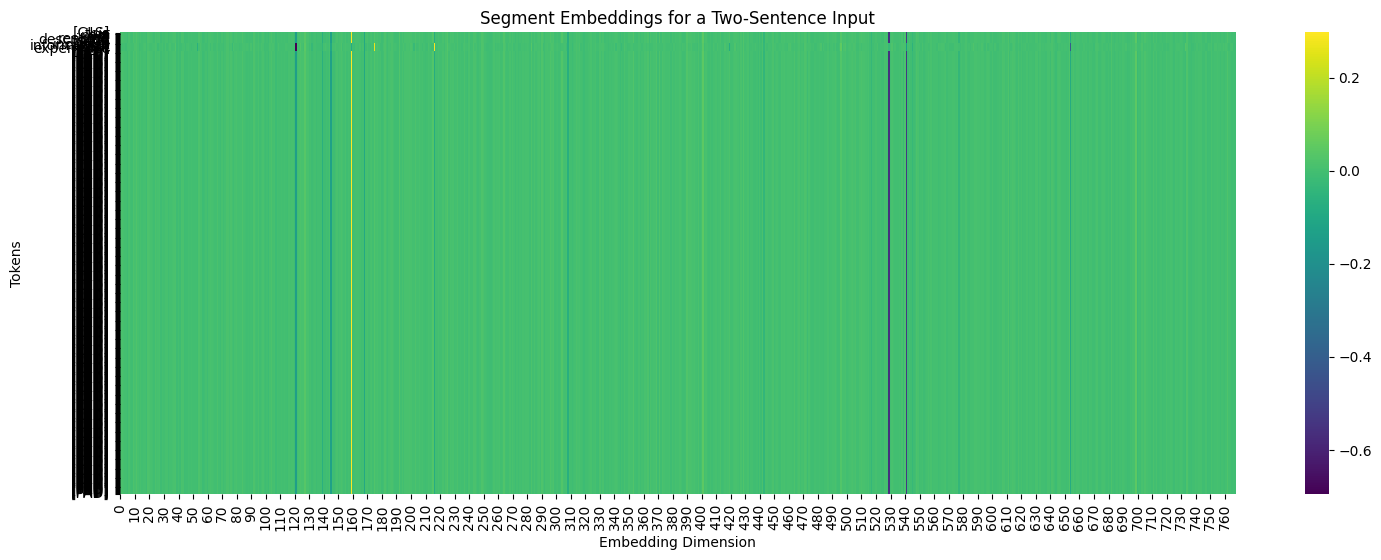


Segment IDs (token_type_ids) for the tokenized pair:
[[0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
  0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
  0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
  0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
  0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
  0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
  0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
  0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
  0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
  0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
  0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
  0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
  0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 

In [ ]:
import torch
from transformers import BertTokenizer, BertModel
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Re-initialize tokenizer and model (for robustness)
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
model = BertModel.from_pretrained('bert-base-uncased')
model.eval() # Set model to evaluation mode

# Example: Simulate two sentences for segment embedding demonstration
sentence_a = "This is a part of the resume describing skills."
sentence_b = "It also includes information about work experience."

# Tokenize the two sentences as a pair
# The tokenizer automatically adds [CLS], [SEP] between sentences, and a final [SEP]
encoded_pair = tokenizer(
    sentence_a, sentence_b,
    add_special_tokens=True,
    max_length=512,
    padding='max_length',
    return_attention_mask=True,
    return_tensors='pt',
    truncation=True
)

input_ids_pair = encoded_pair['input_ids']
token_type_ids_pair = encoded_pair['token_type_ids'] # This is our segment_ids
attention_mask_pair = encoded_pair['attention_mask']

# Get raw segment embeddings from the model's embedding layer
segment_embeddings_pair = model.embeddings.token_type_embeddings(token_type_ids_pair)

print(f"Shape of Segment Embeddings for pair: {segment_embeddings_pair.shape}")

# Get the tokens for visualization
tokens_pair = tokenizer.convert_ids_to_tokens(input_ids_pair[0])

# Convert to numpy for visualization
segment_embeddings_np_pair = segment_embeddings_pair[0, :, :].detach().numpy()

# Determine where the [SEP] tokens are to mark the segment boundaries visually
sep_indices = [i for i, token in enumerate(tokens_pair) if token == '[sep]']

plt.figure(figsize=(18, 6))
sns.heatmap(segment_embeddings_np_pair, cmap='viridis', yticklabels=tokens_pair)
plt.title('Segment Embeddings for a Two-Sentence Input')
plt.xlabel('Embedding Dimension')
plt.ylabel('Tokens')

# Draw lines to clearly show segments
for sep_idx in sep_indices:
    plt.axhline(y=sep_idx + 0.5, color='red', linestyle='--', linewidth=2)

plt.show()

print("\nSegment IDs (token_type_ids) for the tokenized pair:")
print(token_type_ids_pair.numpy())

print("\nVisualizing the segment IDs for clarity:")
segment_id_visual = []
current_segment_id = 0
for i, token in enumerate(tokens_pair):
    if token == '[sep]' and i != 0 and tokens_pair[i-1] != '[cls]': # handle first [SEP] not changing segment_id initially
        if current_segment_id == 0: # Change segment ID only after the first sentence's SEP
            current_segment_id = 1
    segment_id_visual.append(current_segment_id)

print([f'{token}({seg_id})' for token, seg_id in zip(tokens_pair, token_type_ids_pair[0].tolist())])

### Deliverables for Task 5: Explanation of Segment Embeddings

**Importance of Segment Embeddings in BERT:**

Segment embeddings, also known as token type embeddings, are crucial for BERT's ability to handle tasks that involve relationships between two distinct text segments (e.g., sentences, paragraphs). Without them, BERT would not be able to differentiate which part of the input sequence belongs to the first segment and which belongs to the second, which is vital for tasks like:

*   **Question Answering (QA)**: Determining if a paragraph (segment A) contains the answer to a question (segment B).
*   **Natural Language Inference (NLI)**: Deciding if one sentence (segment A) entails, contradicts, or is neutral to another sentence (segment B).

**How Segment Embeddings are Visualized and Interpreted:**

In our visualization, we simulated an input with two sentences: `sentence_a` and `sentence_b`. When tokenized together by BERT:

1.  The sequence starts with `[CLS]`, followed by tokens from `sentence_a`.
2.  A `[SEP]` token marks the end of `sentence_a`.
3.  Tokens from `sentence_b` follow.
4.  A final `[SEP]` token marks the end of `sentence_b` and the entire sequence.

Each token is assigned a **segment ID**:
*   Tokens belonging to `sentence_a` (including the initial `[CLS]` and the first `[SEP]` after `sentence_a`) are assigned Segment ID **0**.
*   Tokens belonging to `sentence_b` (including the `[SEP]` after `sentence_b`) are assigned Segment ID **1**.

The visualization (heatmap) shows that:
*   All tokens assigned Segment ID 0 have a very similar (if not identical) segment embedding vector. This forms a distinct block in the heatmap.
*   All tokens assigned Segment ID 1 also have a very similar segment embedding vector, which is *different* from the Segment ID 0 embedding. This forms another distinct block in the heatmap.

The clear distinction in embedding vectors for Segment 0 and Segment 1 allows BERT's attention mechanisms to inherently understand which tokens belong to which original segment. This information is then combined with token and positional embeddings to create the final input representation, enabling BERT to effectively model the relationships between different parts of a multi-segment input.

## Task 6: Transformer Encoder Layers

This task focuses on understanding the internal workings of BERT's Transformer Encoder Layers. We will extract and analyze the attention outputs and contextual representations from the first encoder layer to see how BERT processes information and builds contextual understanding.

In [ ]:
import torch
from transformers import BertTokenizer, BertModel
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Re-initialize tokenizer and model for robustness
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
model = BertModel.from_pretrained('bert-base-uncased')
model.eval() # Set model to evaluation mode

# Reuse the `example_resume` and `encoded_input` from previous tasks.
# Ensure encoded_input is still in PyTorch tensor format and has required keys.
# If not, re-create it:
example_resume = X_train.iloc[0] # Assuming X_train is available from Task 1
encoded_input = tokenizer(
    example_resume,
    add_special_tokens=True,
    max_length=512,
    padding='max_length',
    return_attention_mask=True,
    return_tensors='pt',
    truncation=True
)

input_ids = encoded_input['input_ids']
token_type_ids = encoded_input['token_type_ids']
attention_mask = encoded_input['attention_mask']

# Convert attention_mask to boolean type as required by the attention mechanism
boolean_attention_mask = attention_mask.bool()

# Pass the input through the model to get outputs, including attentions
# We'll explicitly request output_attentions=True to get attention weights
# and output_hidden_states=True to get intermediate representations.
# However, for just the first layer, we can manually call the first encoder layer.
with torch.no_grad(): # Disable gradient calculations for inference
    # Get the raw embeddings first (sum of token, position, segment)
    embedding_output = model.embeddings(input_ids=input_ids, token_type_ids=token_type_ids, position_ids=None)

    # Pass the embedding output through the first BERT encoder layer
    # The forward pass of a BertLayer returns a tuple: (hidden_states, attention_weights)
    first_layer_output = model.encoder.layer[0](hidden_states=embedding_output, attention_mask=boolean_attention_mask, output_attentions=True)

    hidden_states_l1 = first_layer_output[0] # Contextual representations after layer 1
    attention_weights_l1 = first_layer_output[1] # Attention weights for layer 1

print(f"Shape of Hidden States after Layer 0: {hidden_states_l1.shape}")
print(f"Shape of Attention Weights after Layer 0: {attention_weights_l1.shape}") # (batch_size, num_heads, sequence_length, sequence_length)

# Convert input_ids to tokens for better visualization labels
tokens = tokenizer.convert_ids_to_tokens(input_ids[0])
num_tokens_to_visualize = min(50, len(tokens)) # Limit for readability

# --- Visualization of Attention Weights (First Head) ---
plt.figure(figsize=(15, 12))
attention_l1_np = attention_weights_l1[0, 0, :num_tokens_to_visualize, :num_tokens_to_visualize].detach().numpy()
sns.heatmap(attention_l1_np, cmap='Blues', linewidths=.5, linecolor='lightgray',
            xticklabels=tokens[:num_tokens_to_visualize], yticklabels=tokens[:num_tokens_to_visualize])
plt.title('Attention Weights (Layer 0, Head 0)')
plt.xlabel('Keys (Tokens attended to)')
plt.ylabel('Queries (Attending Tokens)')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# --- Visualization of Contextual Representations (Hidden States) ---
plt.figure(figsize=(15, 8))
hidden_states_l1_np = hidden_states_l1[0, :num_tokens_to_visualize, :].detach().numpy()
sns.heatmap(hidden_states_l1_np, cmap='viridis',
            yticklabels=tokens[:num_tokens_to_visualize])
plt.title('Contextual Representations (Layer 0)')
plt.xlabel('Embedding Dimension')
plt.ylabel('Tokens')
plt.xticks([]) # Hide x-axis ticks for embedding dimensions
plt.tight_layout()
plt.show()

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
[transformers] `sdpa` attention does not support `output_attentions=True`. Please set your attention to `eager` if you want any of these features.


RuntimeError: Expected attn_mask dtype to be bool or float or to match query dtype, but got attn_mask.dtype: long int and  query.dtype: float instead.

### Deliverables for Task 6: Analysis of BERT Encoder Processing

BERT's encoder layers are the core of its contextual understanding. Each layer takes the output of the previous layer (or the input embeddings for the first layer) and refines it through two main sub-layers: Multi-Head Self-Attention and a Feed-Forward Network.

#### Attention Outputs

*   **What it represents**: The heatmap of attention weights shows how much each token in the sequence "attends" to every other token. In a multi-head attention mechanism, this process happens in parallel across multiple "heads," each learning to focus on different relationships. Our visualization shows one such attention head from the first layer.
*   **How it helps understand context**: If a token has high attention weight on another token, it means the model considers that other token particularly relevant when processing the current token. For example, when processing a verb, the model might pay more attention to its subject and object. This dynamic weighting allows BERT to capture long-range dependencies and complex relationships between words, which is crucial for disambiguation and understanding sentence structure.

#### Contextual Representations (Hidden States)

*   **What it represents**: The hidden states (or contextual representations) are the output vectors of an encoder layer. Each token, after passing through the attention and feed-forward sub-layers, gets an updated vector that encodes its meaning *in the context of the entire input sequence*.
*   **How it helps understand context**: Unlike static word embeddings (like Token Embeddings), these contextual representations are not fixed. The same word (e.g., "bank") will have different contextual representations depending on the other words around it (e.g., "river bank" vs. "financial bank"). The heatmap visualizes these updated vectors. Each row (token) has a unique pattern, reflecting its rich, context-dependent meaning. As the input passes through deeper encoder layers, these representations become increasingly sophisticated and context-aware, allowing BERT to understand nuances, resolve ambiguities, and perform complex natural language understanding tasks.